# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 12 — SuperbCommand Incremental Value & Attribution

**Purpose:** isolate and test the incremental value that SuperbCommand contributes to the strongest pre-holdout portfolio architecture.

Notebooks 08–11 leave two principal candidates:

1. **Pure Dual Trend 13/52 + hierarchical inverse volatility**
2. **Portfolio-level walk-forward blend selector**
   - dynamically selects among five coarse SuperbCommand / Dual Trend blends;
   - 5-year training / 1-year test;
   - training Sharpe selection with Calmar tie-breaker.

The walk-forward blend achieved a modest but persistent improvement over pure Dual Trend:

- slightly higher CAGR;
- slightly higher Sharpe;
- slightly higher Sortino;
- essentially unchanged maximum drawdown.

Notebook 12 asks:

> **Exactly when, where, and why does SuperbCommand add value to Dual Trend?**

### Main attribution questions

Notebook 12 examines:

- When does the WF blend differ from pure Dual Trend?
- How much of the total excess return is earned during those periods?
- Which blend states contribute most?
- Which calendar years contribute most?
- Which asset classes appear to explain the differential?
- Does incremental value occur in crisis, recovery, or normal regimes?
- Does the advantage persist after removing individual asset classes?
- Is the incremental Sharpe robust under block bootstrap?
- Is the improvement sufficiently broad to justify the added complexity?

### Important distinction

This notebook is **not** another optimisation exercise.

It performs attribution and falsification on the already-defined architectures.

### Final holdout

Research ends:

**31 December 2025**

The entire 2026 period remains untouched.


In [1]:
# ============================================================
# 12.1 — IMPORTS, DRIVE & CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 12 cannot run with the 2026 holdout unlocked.")

WF_RET_PATH = PATHS["data_processed"] / "08_composite_walkforward_return.parquet"
WF_SELECTION_PATH = PATHS["results"] / "08_composite_walkforward_selection.csv"
BLEND_PANEL_PATH = PATHS["data_processed"] / "08_composite_return_panel.parquet"
BASELINE_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"
AC_PANEL_PATH = PATHS["data_processed"] / "10_asset_class_strategy_return_panel.parquet"

for p in [
    WF_RET_PATH,
    WF_SELECTION_PATH,
    BLEND_PANEL_PATH,
    BASELINE_PATH,
    AC_PANEL_PATH,
]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 12.2 — LOAD PRINCIPAL SERIES
# ============================================================
wf_df = pd.read_parquet(WF_RET_PATH)
wf_selection = pd.read_csv(WF_SELECTION_PATH)
blend_panel = pd.read_parquet(BLEND_PANEL_PATH)
baseline_panel = pd.read_parquet(BASELINE_PATH)
ac_panel = pd.read_parquet(AC_PANEL_PATH)

if wf_df.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in WF return.")
if blend_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in blend panel.")
if baseline_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in baseline panel.")
if ac_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in asset-class panel.")

wf = wf_df.iloc[:, 0].rename("WF_BLEND_SELECTOR")

DUAL_KEY = ("DUAL_TREND_13_52", "hier_inverse_vol")
if DUAL_KEY not in baseline_panel.columns:
    raise KeyError(f"Missing Dual Trend benchmark: {DUAL_KEY}")

dual = baseline_panel[DUAL_KEY].rename("DUAL_TREND")

common = pd.concat([wf, dual], axis=1).dropna()
common = common.loc[:RESEARCH_END]

excess = (common["WF_BLEND_SELECTOR"] - common["DUAL_TREND"]).rename("EXCESS")

print("Common OOS sample:", common.index.min().date(), "→", common.index.max().date())
print("Weeks:", len(common))
display(common.tail())


Common OOS sample: 2011-01-07 → 2025-12-26
Weeks: 782


,WF_BLEND_SELECTOR,DUAL_TREND
date,,
2025-11-28,0.007753,0.006927
2025-12-05,-0.001729,-0.000803
2025-12-12,-0.001575,-0.001138
2025-12-19,0.001880,0.002110
2025-12-26,0.005128,0.006115


## 12.3 Performance functions


In [3]:
# ============================================================
# 12.3 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    d = r[r < 0]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / d.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


## 12.4 When does the WF blend actually differ from Dual Trend?

The WF blend only has scope to add value when its selected blend contains non-zero SuperbCommand exposure.

Notebook 12 reconstructs the annual selected blend and maps it to every weekly OOS observation.


In [4]:
# ============================================================
# 12.4 — MAP SELECTED BLEND TO WEEKLY OBSERVATIONS
# ============================================================
selection_map = (
    wf_selection[["test_year", "selected_blend"]]
    .drop_duplicates()
    .set_index("test_year")["selected_blend"]
)

weekly = common.copy()
weekly["excess"] = excess
weekly["year"] = weekly.index.year
weekly["selected_blend"] = weekly["year"].map(selection_map)

def parse_sc_weight(blend_name):
    # Expected form SC_025_DT_075
    parts = blend_name.split("_")
    return int(parts[1]) / 100.0

weekly["sc_weight"] = weekly["selected_blend"].map(parse_sc_weight)
weekly["dual_weight"] = 1 - weekly["sc_weight"]
weekly["uses_superbcommand"] = weekly["sc_weight"] > 0

display(weekly.tail())


,WF_BLEND_SELECTOR,DUAL_TREND,excess,year,selected_blend,sc_weight,dual_weight,uses_superbcommand
date,,,,,,,,
2025-11-28,0.007753,0.006927,0.000826,2025,SC_075_DT_025,0.75,0.25,True
2025-12-05,-0.001729,-0.000803,-0.000926,2025,SC_075_DT_025,0.75,0.25,True
2025-12-12,-0.001575,-0.001138,-0.000437,2025,SC_075_DT_025,0.75,0.25,True
2025-12-19,0.001880,0.002110,-0.000230,2025,SC_075_DT_025,0.75,0.25,True
2025-12-26,0.005128,0.006115,-0.000987,2025,SC_075_DT_025,0.75,0.25,True


## 12.5 Excess performance conditional on SuperbCommand usage

Compare weeks when:

- WF selector = 100% Dual Trend;
- WF selector includes SuperbCommand.

This is the cleanest first attribution.


In [5]:
# ============================================================
# 12.5 — CONDITIONAL EXCESS PERFORMANCE
# ============================================================
conditional_rows = []

for flag, g in weekly.groupby("uses_superbcommand"):
    conditional_rows.append({
        "uses_superbcommand": bool(flag),
        "weeks": len(g),
        "mean_weekly_excess": g["excess"].mean(),
        "annualised_mean_excess_approx": g["excess"].mean() * WEEKS_PER_YEAR,
        "median_weekly_excess": g["excess"].median(),
        "positive_excess_week_rate": (g["excess"] > 0).mean(),
        "sum_excess": g["excess"].sum(),
        "share_of_total_excess_sum": (
            g["excess"].sum() / weekly["excess"].sum()
            if weekly["excess"].sum() != 0 else np.nan
        ),
    })

conditional_excess = pd.DataFrame(conditional_rows)
display(conditional_excess)


,uses_superbcommand,weeks,mean_weekly_excess,annualised_mean_excess_approx,median_weekly_excess,positive_excess_week_rate,sum_excess,share_of_total_excess_sum
0,False,469,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,True,313,0.000114,0.005945,0.000028,0.523962,0.035785,1.0


## 12.6 Attribution by selected blend state

This shows whether the incremental value comes from:

- 25% SC / 75% DT;
- 50% / 50%;
- 75% SC / 25% DT;
- 100% SC;
- or simply staying in pure Dual Trend.


In [6]:
# ============================================================
# 12.6 — EXCESS BY SELECTED BLEND
# ============================================================
blend_attribution_rows = []

for blend, g in weekly.groupby("selected_blend"):
    blend_attribution_rows.append({
        "selected_blend": blend,
        "sc_weight": g["sc_weight"].iloc[0],
        "weeks": len(g),
        "mean_weekly_excess": g["excess"].mean(),
        "annualised_mean_excess_approx": g["excess"].mean() * WEEKS_PER_YEAR,
        "median_weekly_excess": g["excess"].median(),
        "positive_excess_week_rate": (g["excess"] > 0).mean(),
        "sum_excess": g["excess"].sum(),
        "share_total_excess_sum": (
            g["excess"].sum() / weekly["excess"].sum()
            if weekly["excess"].sum() != 0 else np.nan
        ),
    })

blend_attribution = pd.DataFrame(blend_attribution_rows).sort_values(
    "sc_weight"
)

display(blend_attribution)


,selected_blend,sc_weight,weeks,mean_weekly_excess,annualised_mean_excess_approx,median_weekly_excess,positive_excess_week_rate,sum_excess,share_total_excess_sum
0,SC_000_DT_100,0.00,469,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,SC_025_DT_075,0.25,157,0.000013,0.000665,-0.000003,0.490446,0.002007,0.056074
2,SC_075_DT_025,0.75,156,0.000217,0.011259,0.000143,0.557692,0.033778,0.943926


## 12.7 Calendar-year contribution

Identify which years account for the incremental return.

This is especially important because Notebook 09 showed that recent years contributed disproportionately.


In [7]:
# ============================================================
# 12.7 — YEARLY EXCESS ATTRIBUTION
# ============================================================
year_rows = []

for year, g in weekly.groupby("year"):
    wf_year = (1 + g["WF_BLEND_SELECTOR"]).prod() - 1
    dual_year = (1 + g["DUAL_TREND"]).prod() - 1

    year_rows.append({
        "year": year,
        "selected_blend": g["selected_blend"].iloc[0],
        "sc_weight": g["sc_weight"].iloc[0],
        "wf_return": wf_year,
        "dual_return": dual_year,
        "compound_excess_return": wf_year - dual_year,
        "sum_weekly_excess": g["excess"].sum(),
        "positive_excess_week_rate": (g["excess"] > 0).mean(),
    })

year_attribution = pd.DataFrame(year_rows)

display(
    year_attribution.sort_values(
        "compound_excess_return",
        ascending=False
    )
)


,year,selected_blend,sc_weight,wf_return,dual_return,compound_excess_return,sum_weekly_excess,positive_excess_week_rate
12,2023,SC_075_DT_025,0.75,0.047760,0.033125,0.014635,0.014169,0.596154
13,2024,SC_075_DT_025,0.75,0.123660,0.111042,0.012618,0.011430,0.557692
14,2025,SC_075_DT_025,0.75,0.081983,0.073406,0.008578,0.008179,0.519231
10,2021,SC_025_DT_075,0.25,0.056019,0.053750,0.002269,0.002166,0.452830
11,2022,SC_025_DT_075,0.25,0.025653,0.023793,0.001861,0.001801,0.538462
1,2012,SC_000_DT_100,0.00,-0.002482,-0.002482,0.000000,0.000000,0.000000
0,2011,SC_000_DT_100,0.00,0.033153,0.033153,0.000000,0.000000,0.000000
2,2013,SC_000_DT_100,0.00,0.006092,0.006092,0.000000,0.000000,0.000000
6,2017,SC_000_DT_100,0.00,0.103131,0.103131,0.000000,0.000000,0.000000
5,2016,SC_000_DT_100,0.00,0.081159,0.081159,0.000000,0.000000,0.000000


## 12.8 Cumulative excess-return path

The cumulative difference should ideally grow gradually rather than through one isolated jump.


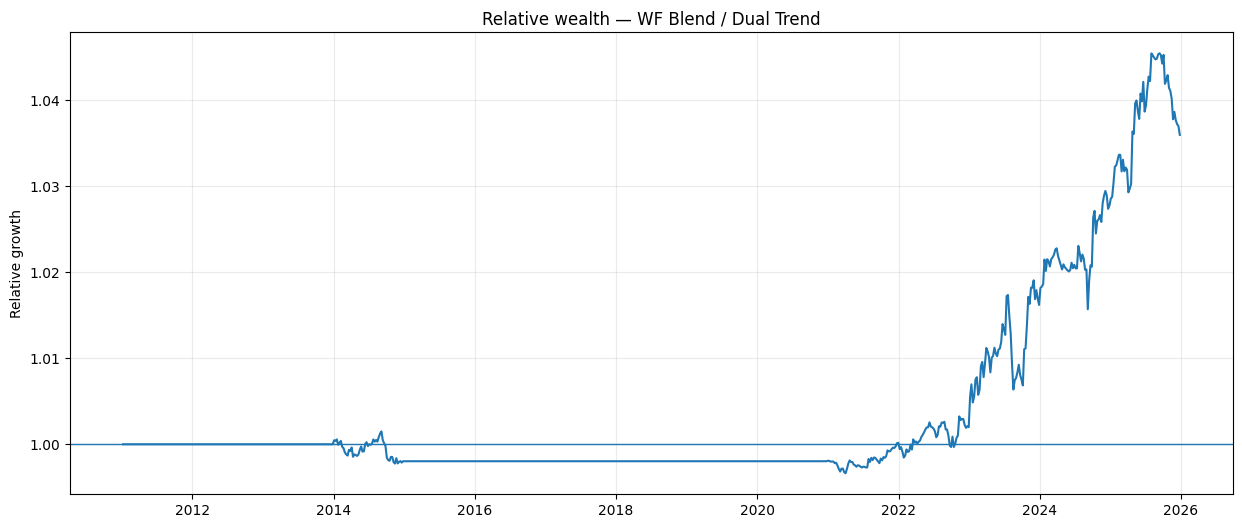

In [8]:
# ============================================================
# 12.8 — CUMULATIVE EXCESS PATH
# ============================================================
cum_wf = (1 + common["WF_BLEND_SELECTOR"]).cumprod()
cum_dual = (1 + common["DUAL_TREND"]).cumprod()

relative_wealth = cum_wf / cum_dual

plt.figure(figsize=(15, 6))
plt.plot(relative_wealth.index, relative_wealth.values)
plt.axhline(1.0, linewidth=1)
plt.title("Relative wealth — WF Blend / Dual Trend")
plt.ylabel("Relative growth")
plt.grid(alpha=0.25)
plt.show()


## 12.9 Rolling incremental Sharpe

Rather than calculating a Sharpe ratio of raw excess returns alone, this section shows the rolling Sharpe difference between the two portfolios.

\[
\Delta Sharpe_t
=
Sharpe_{WF,t}
-
Sharpe_{Dual,t}
\]


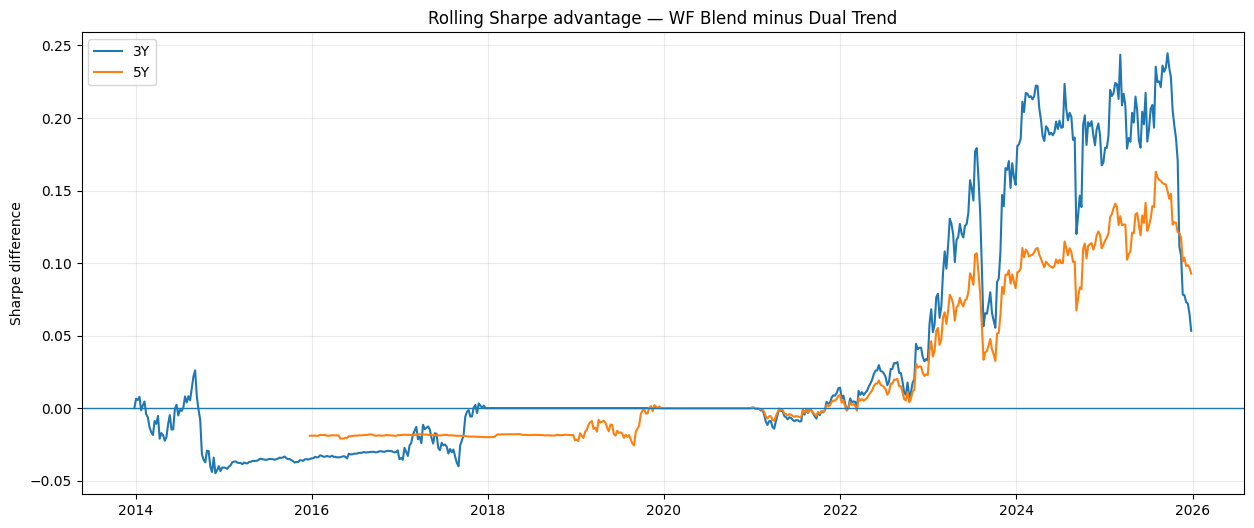

In [9]:
# ============================================================
# 12.9 — ROLLING SHARPE DIFFERENCE
# ============================================================
ROLL_WINDOWS = {
    "3Y": 3 * 52,
    "5Y": 5 * 52,
}

rolling_gap = pd.DataFrame(index=common.index)

for label, window in ROLL_WINDOWS.items():
    wf_mean = common["WF_BLEND_SELECTOR"].rolling(window).mean()
    wf_std = common["WF_BLEND_SELECTOR"].rolling(window).std(ddof=1)
    dt_mean = common["DUAL_TREND"].rolling(window).mean()
    dt_std = common["DUAL_TREND"].rolling(window).std(ddof=1)

    wf_rs = wf_mean / wf_std.replace(0, np.nan) * np.sqrt(WEEKS_PER_YEAR)
    dt_rs = dt_mean / dt_std.replace(0, np.nan) * np.sqrt(WEEKS_PER_YEAR)

    rolling_gap[label] = wf_rs - dt_rs

plt.figure(figsize=(15, 6))

for col in rolling_gap.columns:
    plt.plot(rolling_gap.index, rolling_gap[col], label=col)

plt.axhline(0, linewidth=1)
plt.title("Rolling Sharpe advantage — WF Blend minus Dual Trend")
plt.ylabel("Sharpe difference")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 12.10 Regime attribution using Dual Trend performance state

Without introducing new macro variables, classify each week by the trailing 26-week performance of the Dual Trend portfolio:

- **Strong**: trailing 26-week return > +5%
- **Neutral**: between −5% and +5%
- **Weak**: below −5%

This asks whether SuperbCommand helps especially when conventional trend is struggling.


In [10]:
# ============================================================
# 12.10 — SIMPLE TREND-PORTFOLIO REGIME ATTRIBUTION
# ============================================================
dual_26w = (1 + common["DUAL_TREND"]).rolling(26).apply(np.prod, raw=True) - 1

regime = pd.Series("Neutral", index=common.index)
regime[dual_26w > 0.05] = "Strong"
regime[dual_26w < -0.05] = "Weak"
regime[dual_26w.isna()] = np.nan

weekly["dual_regime_26w"] = regime

regime_rows = []

for reg, g in weekly.dropna(subset=["dual_regime_26w"]).groupby("dual_regime_26w"):
    regime_rows.append({
        "dual_regime_26w": reg,
        "weeks": len(g),
        "mean_weekly_excess": g["excess"].mean(),
        "annualised_mean_excess_approx": g["excess"].mean() * WEEKS_PER_YEAR,
        "positive_excess_week_rate": (g["excess"] > 0).mean(),
        "mean_sc_weight": g["sc_weight"].mean(),
    })

regime_attribution = pd.DataFrame(regime_rows)
display(regime_attribution)


,dual_regime_26w,weeks,mean_weekly_excess,annualised_mean_excess_approx,positive_excess_week_rate,mean_sc_weight
0,Neutral,632,0.000061,0.003189,0.213608,0.189082
1,Strong,125,-0.000024,-0.001236,0.232000,0.294000


## 12.11 Stress-period incremental value

Use the same pre-specified OOS stress periods already employed in prior notebooks.


In [11]:
# ============================================================
# 12.11 — STRESS PERIOD ATTRIBUTION
# ============================================================
STRESS_PERIODS = {
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    g = weekly.loc[start:end].dropna(subset=["WF_BLEND_SELECTOR", "DUAL_TREND"])

    if len(g) == 0:
        continue

    wf_ret = (1 + g["WF_BLEND_SELECTOR"]).prod() - 1
    dt_ret = (1 + g["DUAL_TREND"]).prod() - 1

    stress_rows.append({
        "period": period,
        "weeks": len(g),
        "wf_total_return": wf_ret,
        "dual_total_return": dt_ret,
        "compound_excess_return": wf_ret - dt_ret,
        "wf_max_drawdown": max_drawdown(g["WF_BLEND_SELECTOR"]),
        "dual_max_drawdown": max_drawdown(g["DUAL_TREND"]),
        "mean_sc_weight": g["sc_weight"].mean(),
    })

stress_attribution = pd.DataFrame(stress_rows)
display(stress_attribution)


,period,weeks,wf_total_return,dual_total_return,compound_excess_return,wf_max_drawdown,dual_max_drawdown,mean_sc_weight
0,Euro-area stress,65,0.004813,0.004813,0.000000,-0.018759,-0.018759,0.00
1,COVID crash,12,-0.002513,-0.002513,0.000000,-0.040895,-0.040895,0.00
2,2022 inflation/rates shock,52,0.025653,0.023793,0.001861,-0.020349,-0.022298,0.25


## 12.12 Asset-class differential attribution

Notebook 10 suggested that SuperbCommand and Dual Trend have different relative strengths across asset classes.

For each asset class, compare the local SuperbCommand sleeve with the local Dual Trend sleeve over the same OOS period.

This does **not** reconstruct the final hierarchical portfolio exactly; it is an attribution diagnostic designed to identify where the signal families differ most.


In [12]:
# ============================================================
# 12.12 — ASSET-CLASS SC VS DUAL DIFFERENTIAL
# ============================================================
asset_classes = sorted(ac_panel.columns.get_level_values("asset_class").unique())

ac_rows = []

for asset_class in asset_classes:
    sc_series = ac_panel[(asset_class, "SC_PT_REDUCE_25")]
    dt_series = ac_panel[(asset_class, "DUAL_TREND_13_52")]

    pair = pd.concat(
        [sc_series.rename("sc"), dt_series.rename("dual")],
        axis=1
    ).dropna()

    pair = pair.loc[common.index.min():common.index.max()]

    diff = pair["sc"] - pair["dual"]

    ac_rows.append({
        "asset_class": asset_class,
        "weeks": len(pair),
        "sc_sharpe": sharpe(pair["sc"]),
        "dual_sharpe": sharpe(pair["dual"]),
        "sharpe_gap_sc_minus_dual": sharpe(pair["sc"]) - sharpe(pair["dual"]),
        "mean_weekly_diff": diff.mean(),
        "annualised_mean_diff_approx": diff.mean() * WEEKS_PER_YEAR,
        "positive_diff_week_rate": (diff > 0).mean(),
    })

asset_class_signal_differential = pd.DataFrame(ac_rows).sort_values(
    "sharpe_gap_sc_minus_dual",
    ascending=False
)

display(asset_class_signal_differential)


,asset_class,weeks,sc_sharpe,dual_sharpe,sharpe_gap_sc_minus_dual,mean_weekly_diff,annualised_mean_diff_approx,positive_diff_week_rate
2,equities,782,0.611427,0.532468,0.078959,0.000610,0.031697,0.365729
1,crypto,536,1.194824,1.181032,0.013791,0.000639,0.033212,0.244403
4,rates,782,0.372987,0.442655,-0.069668,0.000023,0.001209,0.401535
3,fx,782,0.231156,0.374379,-0.143223,-0.000090,-0.004675,0.242967
0,commodities,782,0.394244,0.541944,-0.147700,-0.000034,-0.001772,0.415601


## 12.13 Leave-one-asset-class-out attribution

This is a diagnostic reconstruction.

For each omitted asset class:

1. take the remaining asset-class strategy return panel;
2. construct equal-weight class aggregates for the selected WF blend logic and pure Dual Trend;
3. compare their Sharpe difference.

This is not intended to reproduce the exact hierarchical inverse-vol portfolio from Notebook 08. It asks whether the incremental signal relationship depends heavily on one asset class.


In [13]:
# ============================================================
# 12.13 — LEAVE-ONE-ASSET-CLASS-OUT SIGNAL ATTRIBUTION
# ============================================================
# Map blend name to asset-class return series using SC_PT_REDUCE_25 and Dual Trend.
def blend_class_return(asset_class, sc_weight):
    sc = ac_panel[(asset_class, "SC_PT_REDUCE_25")]
    dt = ac_panel[(asset_class, "DUAL_TREND_13_52")]
    return sc_weight * sc + (1 - sc_weight) * dt

# Build weekly selected SC weight series.
weekly_sc_weight = weekly["sc_weight"].reindex(ac_panel.index).ffill()

loo_ac_rows = []

for excluded in [None] + asset_classes:
    included = [
        ac for ac in asset_classes
        if excluded is None or ac != excluded
    ]

    wf_class_series = []
    dt_class_series = []

    for ac in included:
        sc = ac_panel[(ac, "SC_PT_REDUCE_25")]
        dt = ac_panel[(ac, "DUAL_TREND_13_52")]

        dynamic = weekly_sc_weight * sc + (1 - weekly_sc_weight) * dt

        wf_class_series.append(dynamic.rename(ac))
        dt_class_series.append(dt.rename(ac))

    wf_eq = pd.concat(wf_class_series, axis=1).mean(axis=1, skipna=True)
    dt_eq = pd.concat(dt_class_series, axis=1).mean(axis=1, skipna=True)

    pair = pd.concat(
        [wf_eq.rename("wf"), dt_eq.rename("dual")],
        axis=1
    ).dropna()

    pair = pair.loc[common.index.min():common.index.max()]

    loo_ac_rows.append({
        "excluded_asset_class": excluded if excluded is not None else "NONE",
        "included_asset_classes": len(included),
        "wf_sharpe": sharpe(pair["wf"]),
        "dual_sharpe": sharpe(pair["dual"]),
        "sharpe_gap": sharpe(pair["wf"]) - sharpe(pair["dual"]),
        "wf_cagr": cagr(pair["wf"]),
        "dual_cagr": cagr(pair["dual"]),
    })

leave_one_asset_class_out = pd.DataFrame(loo_ac_rows)
display(leave_one_asset_class_out)


,excluded_asset_class,included_asset_classes,wf_sharpe,dual_sharpe,sharpe_gap,wf_cagr,dual_cagr
0,NONE,5,1.193321,1.166513,0.026808,0.128418,0.123372
1,commodities,4,1.144408,1.122199,0.022209,0.147491,0.142335
2,crypto,4,1.011364,0.962991,0.048373,0.038563,0.034969
3,equities,4,1.132554,1.116948,0.015606,0.144191,0.140227
4,fx,4,1.141970,1.116335,0.025635,0.154940,0.148672
5,rates,4,1.153619,1.127850,0.025769,0.154413,0.148261


## 12.14 Incremental-value block bootstrap

Resample the observed WF and Dual Trend returns jointly using 13-week moving blocks.

The central quantity is:

\[
\Delta Sharpe
=
Sharpe_{WF}
-
Sharpe_{Dual}
\]

This complements Notebook 09 by focusing Notebook 12 directly on incremental value.


In [14]:
# ============================================================
# 12.14 — MOVING-BLOCK BOOTSTRAP
# ============================================================
RANDOM_SEED = 20260905
BOOTSTRAP_ITERATIONS = 5000
BLOCK_WEEKS = 13

rng = np.random.default_rng(RANDOM_SEED)

arr = common[["WF_BLEND_SELECTOR", "DUAL_TREND"]].to_numpy()
n = len(arr)

def moving_block_sample(data, block_len, rng):
    nobs = len(data)
    starts = np.arange(0, nobs - block_len + 1)
    blocks = []
    length = 0

    while length < nobs:
        s = int(rng.choice(starts))
        block = data[s:s+block_len]
        blocks.append(block)
        length += len(block)

    return np.vstack(blocks)[:nobs]

boot_rows = []

for i in range(BOOTSTRAP_ITERATIONS):
    sample = moving_block_sample(arr, BLOCK_WEEKS, rng)

    wf_s = pd.Series(sample[:, 0])
    dt_s = pd.Series(sample[:, 1])

    boot_rows.append({
        "iteration": i,
        "sharpe_gap": sharpe(wf_s) - sharpe(dt_s),
        "cagr_gap": cagr(wf_s) - cagr(dt_s),
        "sortino_gap": sortino(wf_s) - sortino(dt_s),
        "max_drawdown_gap": max_drawdown(wf_s) - max_drawdown(dt_s),
    })

bootstrap = pd.DataFrame(boot_rows)

bootstrap_summary = pd.DataFrame({
    "metric": [
        "P(Sharpe gap > 0)",
        "P(CAGR gap > 0)",
        "P(Sortino gap > 0)",
        "P(MaxDD gap > 0)",
        "Median Sharpe gap",
        "Sharpe gap 2.5%",
        "Sharpe gap 97.5%",
        "Median CAGR gap",
        "CAGR gap 2.5%",
        "CAGR gap 97.5%",
    ],
    "value": [
        (bootstrap["sharpe_gap"] > 0).mean(),
        (bootstrap["cagr_gap"] > 0).mean(),
        (bootstrap["sortino_gap"] > 0).mean(),
        (bootstrap["max_drawdown_gap"] > 0).mean(),
        bootstrap["sharpe_gap"].median(),
        bootstrap["sharpe_gap"].quantile(0.025),
        bootstrap["sharpe_gap"].quantile(0.975),
        bootstrap["cagr_gap"].median(),
        bootstrap["cagr_gap"].quantile(0.025),
        bootstrap["cagr_gap"].quantile(0.975),
    ],
})

display(bootstrap_summary)


,metric,value
0,P(Sharpe gap > 0),0.862000
1,P(CAGR gap > 0),0.988200
2,P(Sortino gap > 0),0.779800
3,P(MaxDD gap > 0),0.367600
4,Median Sharpe gap,0.041734
5,Sharpe gap 2.5%,-0.034133
6,Sharpe gap 97.5%,0.122883
7,Median CAGR gap,0.002716
8,CAGR gap 2.5%,0.000343
9,CAGR gap 97.5%,0.005576


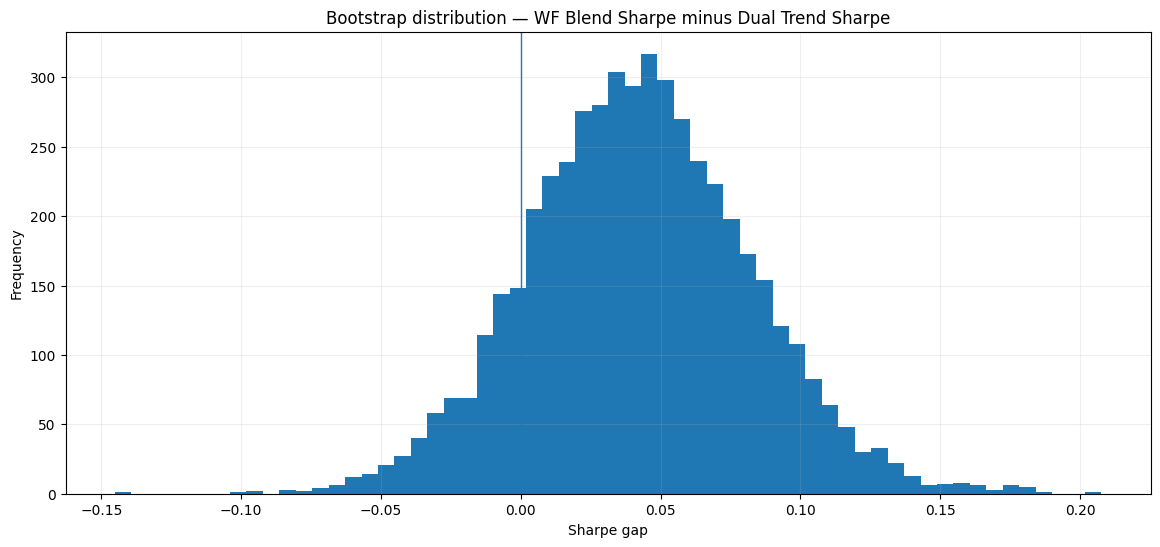

In [15]:
# ============================================================
# 12.15 — BOOTSTRAP SHARPE-GAP DISTRIBUTION
# ============================================================
plt.figure(figsize=(14, 6))
plt.hist(bootstrap["sharpe_gap"], bins=60)
plt.axvline(0, linewidth=1)
plt.title("Bootstrap distribution — WF Blend Sharpe minus Dual Trend Sharpe")
plt.xlabel("Sharpe gap")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()


## 12.16 Incremental-value concentration tests

Revisit the concentration question specifically for the final candidate architecture.

Measure the fraction of cumulative excess return explained by the top:

- 1 week
- 5 weeks
- 10 weeks
- 20 weeks

and compare with leave-one-year-out Sharpe gaps.


In [16]:
# ============================================================
# 12.16 — CONCENTRATION TESTS
# ============================================================
total_excess = weekly["excess"].sum()

concentration_rows = []

for n_top in [1, 5, 10, 20]:
    top_sum = weekly["excess"].nlargest(n_top).sum()

    concentration_rows.append({
        "top_weeks": n_top,
        "top_excess_sum": top_sum,
        "share_of_total_excess_sum": (
            top_sum / total_excess if total_excess != 0 else np.nan
        ),
    })

concentration = pd.DataFrame(concentration_rows)
display(concentration)

loo_year_rows = []

for year in sorted(weekly["year"].unique()):
    g = weekly[weekly["year"] != year]

    loo_year_rows.append({
        "excluded_year": year,
        "wf_sharpe": sharpe(g["WF_BLEND_SELECTOR"]),
        "dual_sharpe": sharpe(g["DUAL_TREND"]),
        "sharpe_gap": sharpe(g["WF_BLEND_SELECTOR"]) - sharpe(g["DUAL_TREND"]),
    })

leave_one_year_out = pd.DataFrame(loo_year_rows)
display(leave_one_year_out)


,top_weeks,top_excess_sum,share_of_total_excess_sum
0,1,0.005982,0.167172
1,5,0.023721,0.662891
2,10,0.039687,1.109059
3,20,0.062950,1.759127


,excluded_year,wf_sharpe,dual_sharpe,sharpe_gap
0,2011,1.516321,1.483099,0.033221
1,2012,1.558530,1.526092,0.032437
2,2013,1.544120,1.511324,0.032796
3,2014,1.494718,1.454650,0.040069
4,2015,1.552538,1.520176,0.032362
5,2016,1.435964,1.400459,0.035505
6,2017,1.353868,1.315593,0.038275
7,2018,1.577312,1.545738,0.031574
8,2019,1.387581,1.350261,0.037319
9,2020,1.549036,1.518242,0.030794


## 12.17 Decision-oriented evidence scorecard

The WF blend should only be retained if the incremental SuperbCommand contribution survives several tests.

Evidence considered:

- observed Sharpe improvement;
- observed Sortino improvement;
- positive block-bootstrap probability;
- positive leave-one-year-out majority;
- positive excess when SuperbCommand is actually used;
- improvement not dependent on a single asset class;
- stress-period contribution.


In [17]:
# ============================================================
# 12.17 — INCREMENTAL VALUE SCORECARD
# ============================================================
obs_wf = metrics(common["WF_BLEND_SELECTOR"])
obs_dt = metrics(common["DUAL_TREND"])

sc_use_row = conditional_excess[
    conditional_excess["uses_superbcommand"] == True
].iloc[0]

loo_positive_share = (leave_one_year_out["sharpe_gap"] > 0).mean()

loo_ac_nonfull = leave_one_asset_class_out[
    leave_one_asset_class_out["excluded_asset_class"] != "NONE"
]

scorecard = pd.DataFrame([
    {
        "test": "Observed Sharpe improvement",
        "passes": obs_wf["sharpe"] > obs_dt["sharpe"],
        "evidence": obs_wf["sharpe"] - obs_dt["sharpe"],
    },
    {
        "test": "Observed Sortino improvement",
        "passes": obs_wf["sortino"] > obs_dt["sortino"],
        "evidence": obs_wf["sortino"] - obs_dt["sortino"],
    },
    {
        "test": "Bootstrap P(Sharpe gap > 0) > 50%",
        "passes": (bootstrap["sharpe_gap"] > 0).mean() > 0.5,
        "evidence": (bootstrap["sharpe_gap"] > 0).mean(),
    },
    {
        "test": "Leave-one-year-out Sharpe majority",
        "passes": loo_positive_share > 0.5,
        "evidence": loo_positive_share,
    },
    {
        "test": "Weeks using SuperbCommand have positive mean excess",
        "passes": sc_use_row["mean_weekly_excess"] > 0,
        "evidence": sc_use_row["annualised_mean_excess_approx"],
    },
    {
        "test": "Positive Sharpe gap after majority of asset-class exclusions",
        "passes": (loo_ac_nonfull["sharpe_gap"] > 0).mean() > 0.5,
        "evidence": (loo_ac_nonfull["sharpe_gap"] > 0).mean(),
    },
])

display(scorecard)

print(
    "Tests supporting incremental SuperbCommand value:",
    int(scorecard["passes"].sum()),
    "of",
    len(scorecard)
)


,test,passes,evidence
0,Observed Sharpe improvement,True,0.031991
1,Observed Sortino improvement,True,0.043246
2,Bootstrap P(Sharpe gap > 0) > 50%,True,0.862000
3,Leave-one-year-out Sharpe majority,True,1.000000
4,Weeks using SuperbCommand have positive mean e...,True,0.005945
5,Positive Sharpe gap after majority of asset-cl...,True,1.000000


Tests supporting incremental SuperbCommand value: 6 of 6


## 12.18 Save outputs


In [18]:
# ============================================================
# 12.18 — SAVE OUTPUTS
# ============================================================
WEEKLY_PATH = PATHS["results"] / "12_weekly_incremental_attribution.csv"
CONDITIONAL_PATH = PATHS["results"] / "12_conditional_excess_superbcommand_usage.csv"
BLEND_ATTR_PATH = PATHS["results"] / "12_blend_state_attribution.csv"
YEAR_ATTR_PATH = PATHS["results"] / "12_yearly_incremental_attribution.csv"
REGIME_PATH = PATHS["results"] / "12_dualtrend_regime_attribution.csv"
STRESS_PATH = PATHS["results"] / "12_stress_incremental_attribution.csv"
AC_DIFF_PATH = PATHS["results"] / "12_asset_class_signal_differential.csv"
LOO_AC_PATH = PATHS["results"] / "12_leave_one_asset_class_out.csv"
BOOT_PATH = PATHS["results"] / "12_incremental_bootstrap.csv"
BOOT_SUMMARY_PATH = PATHS["results"] / "12_incremental_bootstrap_summary.csv"
CONCENTRATION_PATH = PATHS["results"] / "12_incremental_concentration.csv"
LOO_YEAR_PATH = PATHS["results"] / "12_incremental_leave_one_year_out.csv"
SCORECARD_PATH = PATHS["results"] / "12_incremental_value_scorecard.csv"

weekly.to_csv(WEEKLY_PATH)
conditional_excess.to_csv(CONDITIONAL_PATH, index=False)
blend_attribution.to_csv(BLEND_ATTR_PATH, index=False)
year_attribution.to_csv(YEAR_ATTR_PATH, index=False)
regime_attribution.to_csv(REGIME_PATH, index=False)
stress_attribution.to_csv(STRESS_PATH, index=False)
asset_class_signal_differential.to_csv(AC_DIFF_PATH, index=False)
leave_one_asset_class_out.to_csv(LOO_AC_PATH, index=False)
bootstrap.to_csv(BOOT_PATH, index=False)
bootstrap_summary.to_csv(BOOT_SUMMARY_PATH, index=False)
concentration.to_csv(CONCENTRATION_PATH, index=False)
leave_one_year_out.to_csv(LOO_YEAR_PATH, index=False)
scorecard.to_csv(SCORECARD_PATH, index=False)

print("Saved Notebook 12 outputs.")


Saved Notebook 12 outputs.


## 12.19 Validation suite

Notebook 12 passes only if:

- 2026 remains absent;
- WF blend and Dual Trend share the same OOS sample;
- every test year has exactly one selected blend;
- weekly SuperbCommand weight is derived only from the already-completed walk-forward selector;
- no new signal hyperparameters are optimised;
- bootstrap uses 5,000 joint 13-week blocks;
- all output files are written.


In [19]:
# ============================================================
# 12.19 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = common.index.max() <= RESEARCH_END
checks["2026_absent"] = not (common.index.year == 2026).any()

checks["same_oos_sample"] = (
    common["WF_BLEND_SELECTOR"].notna().all()
    and common["DUAL_TREND"].notna().all()
)

checks["one_blend_per_test_year"] = (
    wf_selection.groupby("test_year")["selected_blend"].nunique().eq(1).all()
)

checks["weekly_blend_mapping_complete"] = weekly["selected_blend"].notna().all()

checks["bootstrap_5000"] = len(bootstrap) == 5000
checks["bootstrap_block_13"] = BLOCK_WEEKS == 13

checks["outputs_written"] = all(
    p.exists()
    for p in [
        WEEKLY_PATH,
        CONDITIONAL_PATH,
        BLEND_ATTR_PATH,
        YEAR_ATTR_PATH,
        REGIME_PATH,
        STRESS_PATH,
        AC_DIFF_PATH,
        LOO_AC_PATH,
        BOOT_PATH,
        BOOT_SUMMARY_PATH,
        CONCENTRATION_PATH,
        LOO_YEAR_PATH,
        SCORECARD_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 12 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 12 STATUS: PASS")
print("=" * 78)
print("Incremental SuperbCommand attribution completed.")
print("No signal hyperparameters were optimised.")
print("2026 final holdout: NOT ACCESSED")
print("Review whether SuperbCommand earns its place in the frozen architecture.")


                        check  passed
               holdout_absent    True
                  2026_absent    True
              same_oos_sample    True
      one_blend_per_test_year    True
weekly_blend_mapping_complete    True
               bootstrap_5000    True
           bootstrap_block_13    True
              outputs_written    True

NOTEBOOK 12 STATUS: PASS
Incremental SuperbCommand attribution completed.
No signal hyperparameters were optimised.
2026 final holdout: NOT ACCESSED
Review whether SuperbCommand earns its place in the frozen architecture.


In [20]:
# ============================================================
# 12.20 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "12",
    "notebook_name": "SuperbCommand Incremental Value & Attribution",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "principal_comparison": [
        "PORTFOLIO_WF_BLEND",
        "DUAL_TREND_13_52__hier_inverse_vol",
    ],
    "incremental_signal": "SuperbCommand PT_REDUCE_25 sleeve inside portfolio-level WF blend",
    "bootstrap": {
        "method": "moving_block_bootstrap",
        "iterations": BOOTSTRAP_ITERATIONS,
        "block_weeks": BLOCK_WEEKS,
        "joint_resampling": True,
        "random_seed": RANDOM_SEED,
    },
    "signal_hyperparameters_optimised": False,
    "outputs": {
        "weekly_incremental_attribution": str(WEEKLY_PATH),
        "conditional_superbcommand_usage": str(CONDITIONAL_PATH),
        "blend_state_attribution": str(BLEND_ATTR_PATH),
        "yearly_attribution": str(YEAR_ATTR_PATH),
        "dualtrend_regime_attribution": str(REGIME_PATH),
        "stress_attribution": str(STRESS_PATH),
        "asset_class_signal_differential": str(AC_DIFF_PATH),
        "leave_one_asset_class_out": str(LOO_AC_PATH),
        "bootstrap": str(BOOT_PATH),
        "bootstrap_summary": str(BOOT_SUMMARY_PATH),
        "concentration": str(CONCENTRATION_PATH),
        "leave_one_year_out": str(LOO_YEAR_PATH),
        "incremental_value_scorecard": str(SCORECARD_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "12_superbcommand_incremental_value_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/12_superbcommand_incremental_value_manifest.json


---

# End of Notebook 12

## Main research question

\[
\boxed{\text{Does SuperbCommand provide sufficiently broad incremental value to justify inclusion alongside Dual Trend?}}
\]

Notebook 12 does not search for a better blend.

It isolates the existing WF blend's incremental behaviour through:

- conditional SuperbCommand-usage attribution;
- blend-state attribution;
- year-by-year contribution;
- rolling Sharpe differential;
- simple performance-regime attribution;
- stress analysis;
- asset-class signal differential;
- leave-one-asset-class-out tests;
- 5,000-run moving-block bootstrap;
- concentration and leave-one-year-out diagnostics.

### Decision rule

If the incremental improvement is broad and survives these falsification tests, SuperbCommand earns a place in the final candidate architecture.

If the improvement is narrow, asset-class dependent, or statistically fragile, pure Dual Trend remains the more parsimonious final candidate.

### Final holdout

**2026 remains completely untouched.**
